In [2]:
import os
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import cv2

In [12]:
base = Path("../data/d-fire")

sum = 0
for split in ["train", "val", "test"]:
    imgDir = base / split / "images"
    count = len(list(imgDir.glob("*.jpg")))
    print(imgDir)
    print(count)
    sum += count
print(sum)

..\data\d-fire\train\images
14122
..\data\d-fire\val\images
3099
..\data\d-fire\test\images
4306
21527


In [ ]:
base = Path("../data/d-fire/test")

jpg_files = list(base.glob("images/*.jpg"))
txt_files = list(base.glob("labels/*.txt"))
print(f"JPG'ler: {len(jpg_files)}")
print(f"TXT'ler: {len(txt_files)}")



jpg_names = {f.stem for f in jpg_files}  # "image.jpg" → "image"
txt_names = {f.stem for f in txt_files}  # "image.txt" → "image"

# Karşılaştır
missing = jpg_names - txt_names
matched = jpg_names & txt_names

print(f"\n✓ Having TXT: {len(matched)}")
print(f"✗ Missing TXT file: {len(missing)}")
print(f"\n All Missing TXT Files: {missing}")



JPG'ler: 4306
TXT'ler: 4306

✓ TXT'i olan: 4306
✗ TXT'i olmayan: 0

Oksayan dosyalar: set()
0


In [36]:
counter = Counter()

base = Path("../data/d-fire")

trainDir = base / "train" / "labels"

for label in trainDir.glob("*.txt"):
    with open(label) as f:
        for line in f:
            line = line.strip()
            if line:
                class_id = int(line.split()[0])
                counter[class_id] +=1

print(f"smoke(0): {counter[0]}")
print(f"fire(1): {counter[1]}")

smoke(0): 9013
fire(1): 11565


In [9]:
counter = Counter()
background = 0
base = Path("../data/d-fire")

trainDir = base / "train" / "labels"
for label in trainDir.glob("*.txt"):
    if label.stat().st_size == 0:
        background += 1
print(background)

6458


In [ ]:
def show_image_with_boxes(img_path, label_path):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
    h, w = img.shape[:2]  
    
    names = {0: "smoke", 1: "fire"}
    colors = {0: (128, 128, 128), 1: (255, 0, 0)}  
    
    with open(label_path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            cls, cx, cy, bw, bh = map(float, line.split())
            cx, cy, bw, bh = cx*w, cy*h, bw*w, bh*h
            x1 = int(cx - bw/2)
            y1 = int(cy - bh/2)
            x2 = int(cx + bw/2)
            y2 = int(cy + bh/2)
            cls = int(cls)
            cv2.rectangle(img, (x1, y1), (x2, y2), colors[cls], 2)
            cv2.putText(img, names[cls], (x1, y1-5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, colors[cls], 2)
    
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

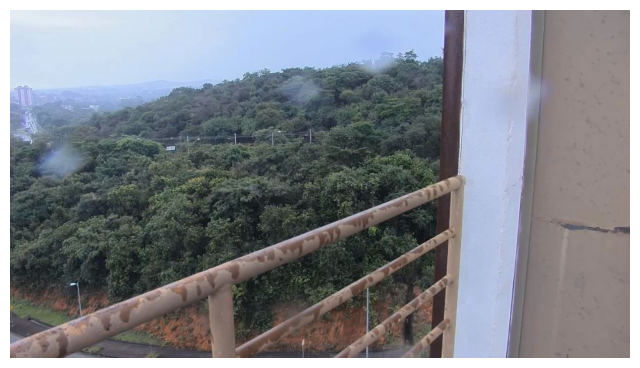

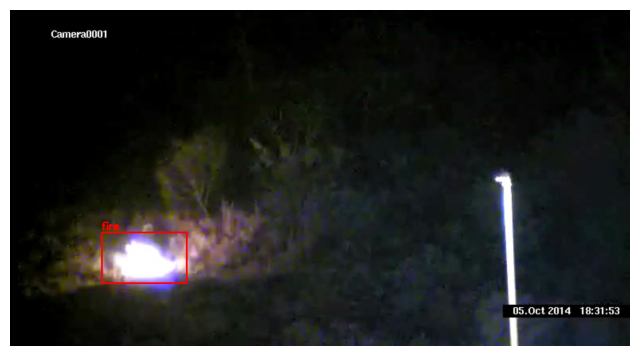

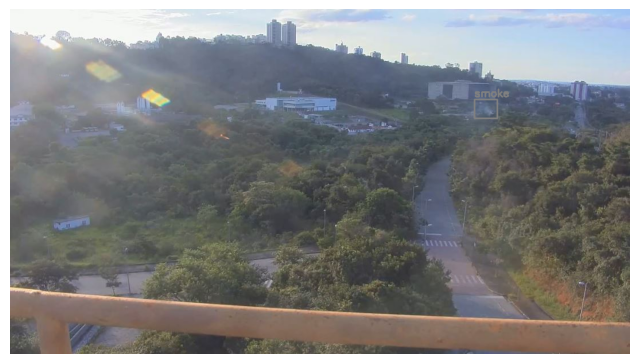

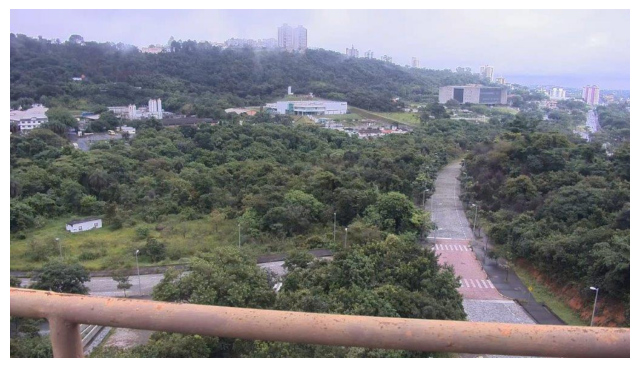

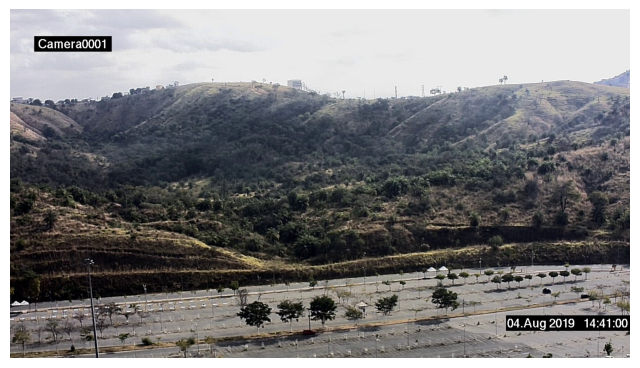

In [ ]:
img_dir = base / "train" / "images"
lbl_dir = base / "train" / "labels"

sample_imgs = list(img_dir.glob("*.jpg"))[:5]  

for img_path in sample_imgs:
    label_path = lbl_dir / (img_path.stem + ".txt") 
    if label_path.exists():
        show_image_with_boxes(img_path, label_path)

In [ ]:
sizes = Counter()
imgDir = base / "train" / "images"
for imgPath in list(imgDir.glob("*.jpg"))[:500]:
    img = cv2.imread(str(imgPath))
    sizes[img.shape[:2]] +=1

for size, count in sizes.most_common(10):
    print(f"{size}: {count} images")

(720, 1280): 412 götüntü
(450, 800): 40 götüntü
(432, 768): 28 götüntü
(610, 1086): 1 götüntü
(598, 1103): 1 götüntü
(604, 1087): 1 götüntü
(576, 1024): 1 götüntü
(720, 1269): 1 götüntü
(711, 1273): 1 götüntü
(706, 1268): 1 götüntü
